In [1]:
import os

# Subir un nivel respecto a la carpeta actual
os.chdir("..")

import numpy as np
from globals import SAMPLE_RATE
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from Utils import from_matrix_to_preset, denormalize_preset, pretty_print, get_audio, split_audio
import numpy as np
import matplotlib.pyplot as plt
from Optimizers import search_with_DE, search_with_CMA, evaluate_target, render_presets

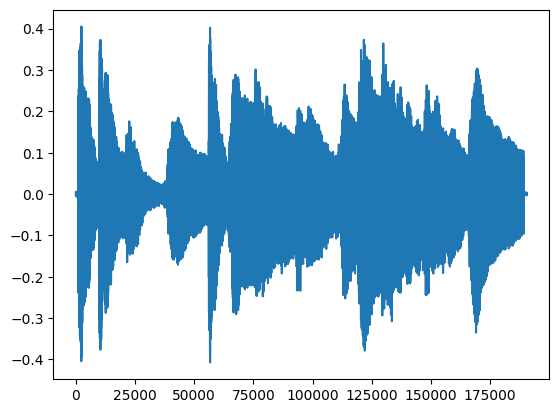

In [2]:
audio_path = 'C:/Users/bryan/Documents/GitHub/Synth/presets/nokia.mp3'
audio = get_audio(audio_path)

plt.plot(audio)
plt.show()
Audio(audio, rate=SAMPLE_RATE)

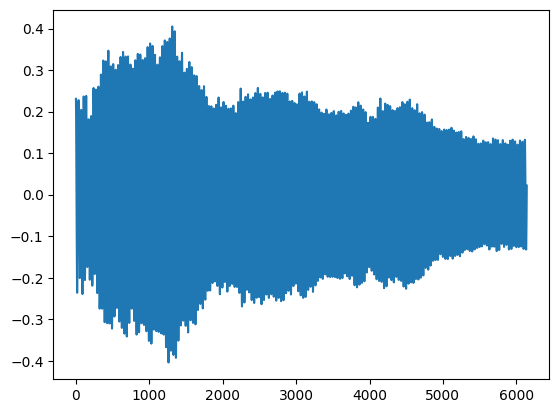

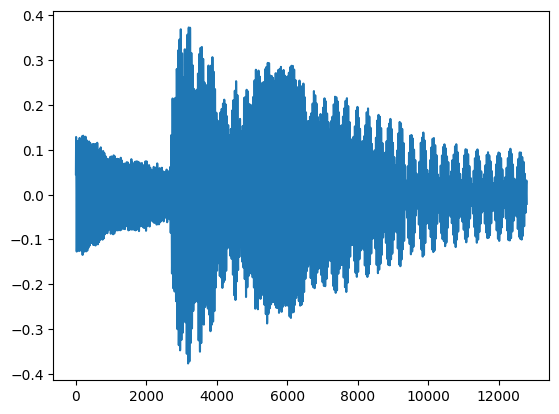

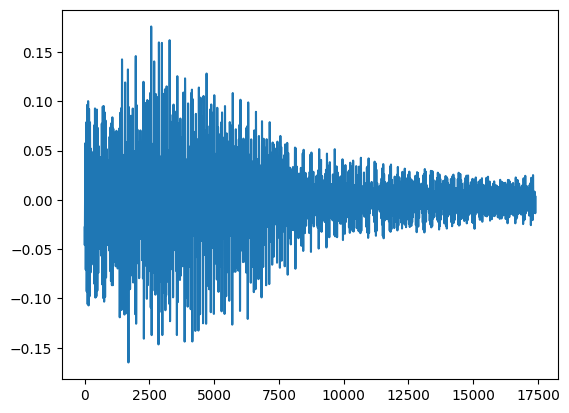

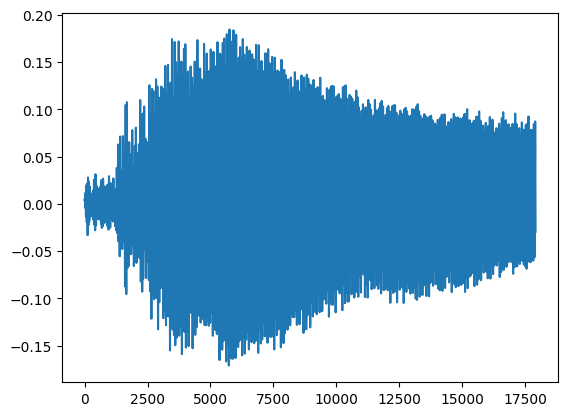

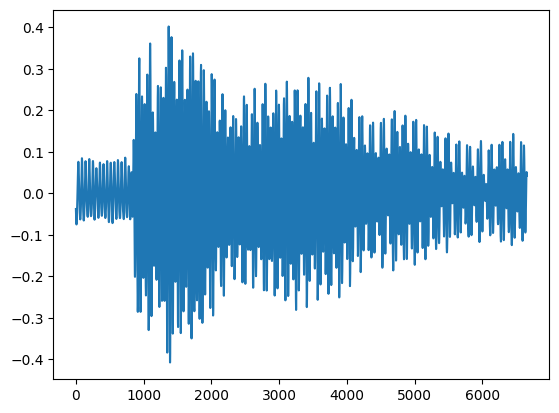

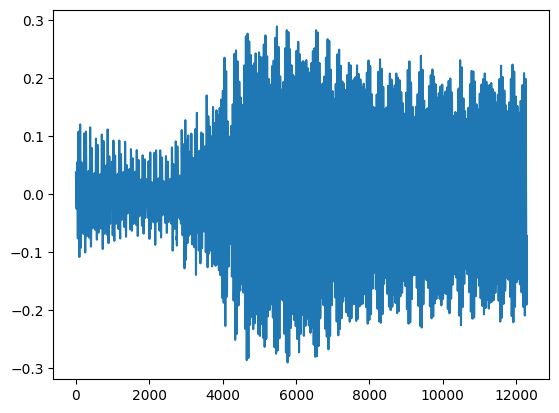

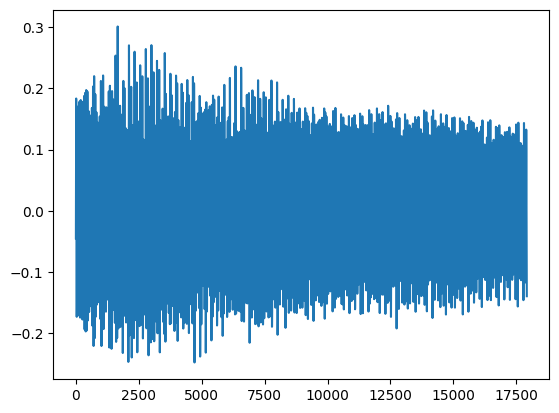

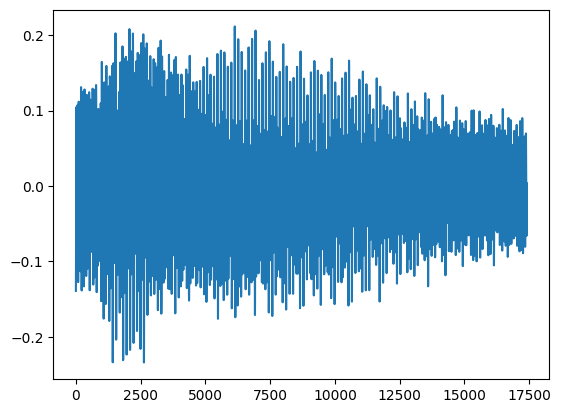

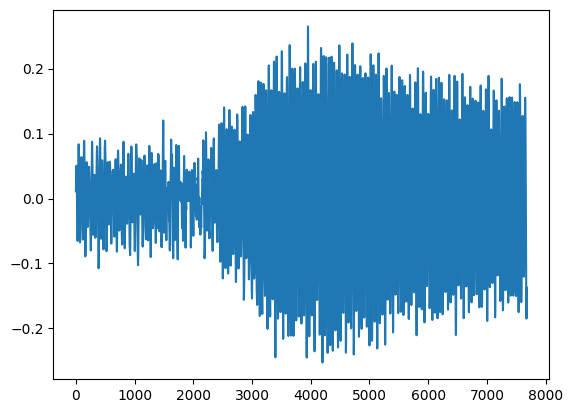

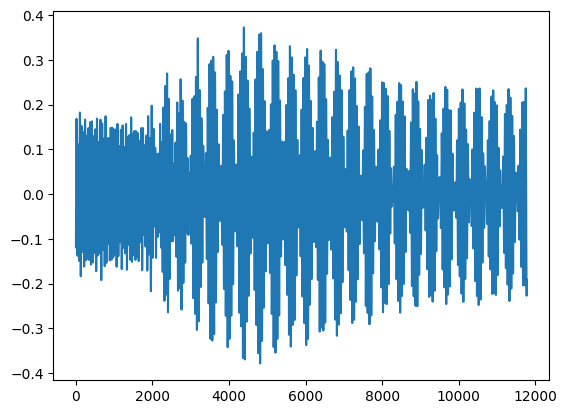

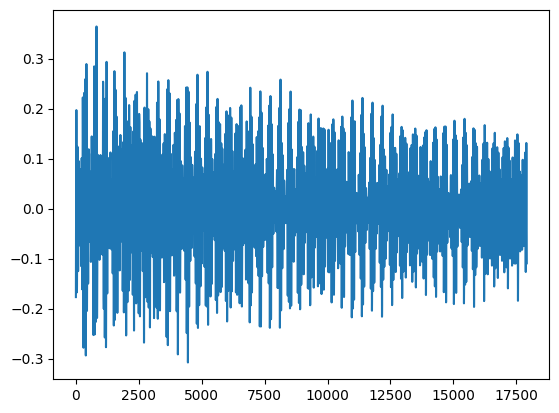

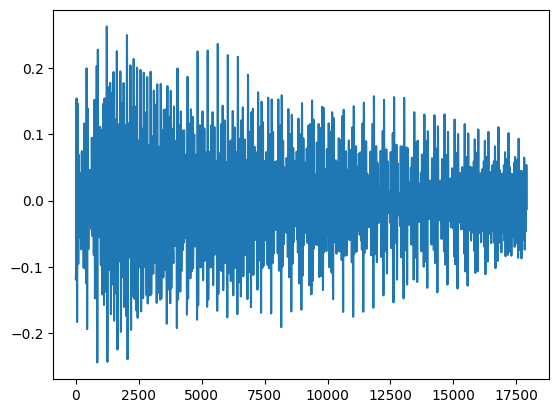

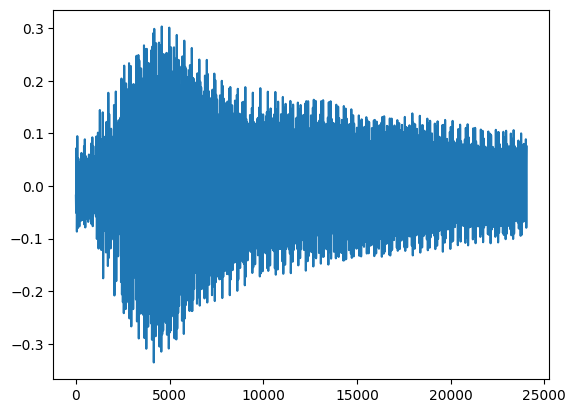

Pieces 13


In [3]:
audio_segments = split_audio(audio, SAMPLE_RATE)

for audio_segment in audio_segments:
    plt.plot(audio_segment)
    plt.show()
    display(Audio(audio_segment, rate=SAMPLE_RATE))

print('Pieces', len(audio_segments))

In [4]:
estimated_presets = []
i = 1
last_best = None

if __name__ == '__main__':
    for audio_segment in audio_segments:
        print('Piece', i)
        target_C = evaluate_target(np.expand_dims(audio_segment, axis=0))
        duration = len(audio_segment) / SAMPLE_RATE
        if last_best is None:
            best, _ = search_with_DE(target_C, duration, disp=False, maxiter=350)
            best, _ = search_with_CMA(target_C, duration, best)
        else:
            best, _ = search_with_CMA(target_C, duration, last_best)

        last_best = best
        estimated_presets.append((best, duration))
        i+=1

Piece 1


c:\Users\bryan\Documents\GitHub\Synth\venv\Lib\site-packages\scipy\optimize\_differentialevolution.py:487: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=128811, Tue Mar 31 18:12:20 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=88660, Tue Mar 31 18:12:58 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=153396, Tue Mar 31 18:13:28 2026)
Piece 2
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=72431, Tue Mar 31 18:14:19 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=110494, Tue Mar 31 18:15:44 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=61133, Tue Mar 31 18:17:21 2026)
Piece 3
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=108493, Tue Mar 31 18:19:26 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=74344, Tue Mar 31 18:22:12 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=128104, Tue Mar 31 18:24:00 2026)
Piece 4
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 29 (seed=115310, Tue Mar 31 18:25:20 2026)
(15_w,30)-aCMA-ES (mu_w=8.6,w_1=20%) in dimension 

In [5]:
predicted_joined_audio = []

for preset, duration in estimated_presets:
    preset = np.expand_dims(preset, axis=0)
    # error = evaluate_presets((denormalize_preset(from_matrix_to_preset(preset)), target_C, duration))
    # print('Error', error)
    # target_audio = np.expand_dims(audio_segments[0], axis=0)
    predicted_audio = render_presets(denormalize_preset(from_matrix_to_preset(preset)), duration)
    predicted_joined_audio.append(predicted_audio[0])

    denormalized_predicted_preset = denormalize_preset(from_matrix_to_preset(preset))
    pretty_print(denormalized_predicted_preset)

predicted_joined_audio = np.concatenate(predicted_joined_audio, axis=0)

{
  osc1_shape:   [
    0.9567790205229327
  ]
  osc1_phase:   [
    0.014170910048067982
  ]
  osc1_volume:   [
    0.25636211981049456
  ]
  osc1_freq:   [
    21188.766324274642
  ]
  osc2_shape:   [
    0.6450999749990388
  ]
  osc2_phase:   [
    0.4871200757264704
  ]
  osc2_volume:   [
    0.12314072013781648
  ]
  osc2_freq:   [
    330.36477519708967
  ]
  osc3_shape:   [
    0.4037760081985343
  ]
  osc3_phase:   [
    0.29797703124445124
  ]
  osc3_volume:   [
    0.5446614282916941
  ]
  osc3_freq:   [
    6752.386596786425
  ]
  osc4_shape:   [
    2.309367997566566
  ]
  osc4_phase:   [
    0.5823856922547141
  ]
  osc4_volume:   [
    0.7699569914149458
  ]
  osc4_freq:   [
    1322.7756879648896
  ]
  oscnoise_volume:   [
    0.3970735844184202
  ]
  filter_envelope_attack:   [
    0.4136095099866826
  ]
  filter_envelope_decay:   [
    0.14814018538525742
  ]
  filter_envelope_sustain:   [
    0.42956212102897207
  ]
  filter_envelope_release:   [
    0.438138794464659

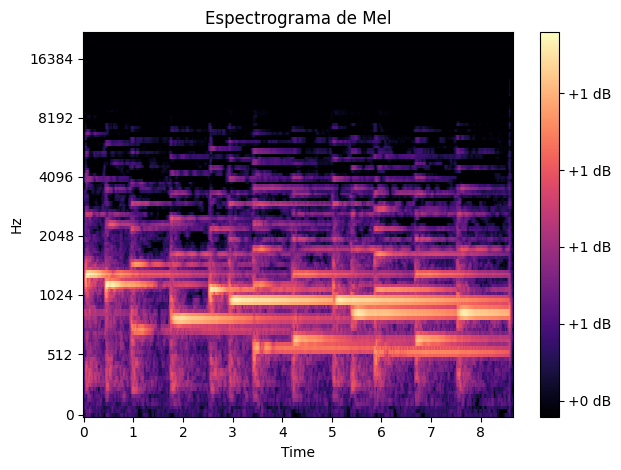

In [6]:
spect = evaluate_target(np.array([audio]))[0]
librosa.display.specshow(spect, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel')
plt.tight_layout()
plt.show()

display(Audio(audio, rate=SAMPLE_RATE))

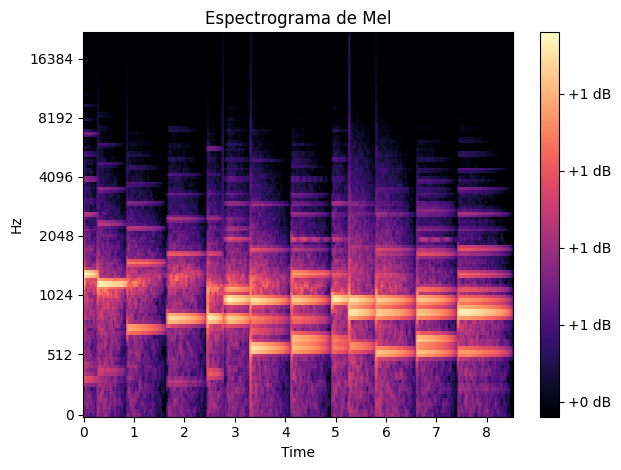

In [7]:
spect = evaluate_target(np.array([predicted_joined_audio]))[0]
librosa.display.specshow(spect, sr=SAMPLE_RATE, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Mel')
plt.tight_layout()
plt.show()

display(Audio(predicted_joined_audio, rate=SAMPLE_RATE))